# Launch data analysis

Step 1: load and clean the launch data pulled by `fetch_data.py`.

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

df = pd.read_csv("data/launches.csv", parse_dates=["net"])
print(df.shape)
df.info()
df.head()

(3000, 15)
<class 'pandas.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype              
---  ------         --------------  -----              
 0   id             3000 non-null   str                
 1   name           3000 non-null   str                
 2   net            3000 non-null   datetime64[us, UTC]
 3   status         3000 non-null   str                
 4   fail_reason    99 non-null     str                
 5   provider       3000 non-null   str                
 6   provider_type  3000 non-null   str                
 7   rocket         3000 non-null   str                
 8   rocket_family  2608 non-null   str                
 9   mission_type   2693 non-null   str                
 10  orbit          2680 non-null   str                
 11  orbit_abbrev   2664 non-null   str                
 12  pad            3000 non-null   str                
 13  location       3000 non-null   str              

,id,name,net,status,fail_reason,provider,provider_type,rocket,rocket_family,mission_type,orbit,orbit_abbrev,pad,location,country_code
0,4b458e2d-9a80-4819-88d6-108739c16c33,Kosmos-3M | Nadezhda-M,2002-09-26 14:27:14+00:00,Launch Successful,NaN,Production Corporation Polyot,Commercial,Kosmos-3M,Kosmos,Navigation,Polar Orbit,PO,132/1 (132L),"Plesetsk Cosmodrome, Russian Federation",RUS
1,763dcd6e-c3e1-46d9-9fa9-6edc2076c107,Space Shuttle Atlantis / OV-104 | STS-112,2002-10-07 19:45:51+00:00,Launch Successful,NaN,United Space Alliance,Commercial,Space Shuttle,NaN,Human Exploration,Low Earth Orbit,LEO,Launch Complex 39B,"Kennedy Space Center, FL, USA",USA
2,5ec966fd-6feb-4f07-894c-17c8ccb852ab,Soyuz-U-PVB | Foton-M No. 1,2002-10-15 18:20:00+00:00,Launch Failure,NaN,Russian Space Forces,Government,Soyuz-U-PVB,Soyuz,Earth Science,Low Earth Orbit,LEO,43/3 (43L),"Plesetsk Cosmodrome, Russian Federation",RUS
3,29dada6b-989c-4920-b410-2f7bfb2a1c30,Proton-K/17S40 | Integral,2002-10-17 04:41:00+00:00,Launch Successful,NaN,Khrunichev State Research and Production Space...,Government,Proton-K/17S40,Proton / UR-500,Astrophysics,Elliptical Orbit,Elliptical,200/39 (200L),"Baikonur Cosmodrome, Republic of Kazakhstan",KAZ
4,920a9286-2254-4747-aceb-0e42d20867e3,Long March 4B | Zi Yuan-2 02 xing,2002-10-27 03:17:00+00:00,Launch Successful,NaN,China Aerospace Science and Technology Corpora...,Government,Long March 4B,Long March,Earth Science,Sun-Synchronous Orbit,SSO,Launch Complex 7,"Taiyuan Satellite Launch Center, People's Repu...",CHN


Check which status labels exist before deciding what counts as success or failure.

In [17]:
df["status"].value_counts()

status
Launch Successful               2837
Launch Failure                   141
Launch was a Partial Failure      22
Name: count, dtype: int64

## Clean

Keep only launches that have an outcome (drops scheduled or unknown ones). If the labels above differ from the map below, edit the map.

In [18]:
outcome_map = {
    "Launch Successful": "success",
    "Launch Failure": "failure",
    "Launch was a Partial Failure": "partial failure",
}

df["outcome"] = df["status"].map(outcome_map)
df = df.dropna(subset=["outcome"]).copy()
df["success"] = df["outcome"] == "success"
df["year"] = df["net"].dt.year

print(df.shape)
df["outcome"].value_counts()

(3000, 18)


outcome
success            2837
failure             141
partial failure      22
Name: count, dtype: int64

Tidy text columns and handle missing values.

In [19]:
text_cols = ["provider", "rocket", "rocket_family", "orbit", "orbit_abbrev", "country_code"]
for col in text_cols:
    df[col] = df[col].astype("string").str.strip()

df[["orbit", "orbit_abbrev"]] = df[["orbit", "orbit_abbrev"]].fillna("Unknown")

df.isna().mean().sort_values(ascending=False)

fail_reason      0.967000
rocket_family    0.130667
mission_type     0.102333
id               0.000000
name             0.000000
net              0.000000
provider         0.000000
status           0.000000
rocket           0.000000
provider_type    0.000000
orbit            0.000000
orbit_abbrev     0.000000
pad              0.000000
location         0.000000
country_code     0.000000
outcome          0.000000
success          0.000000
year             0.000000
dtype: float64

Look at the categories before grouping anything. Orbit and provider names often need merging.

In [20]:
print(df["orbit_abbrev"].value_counts().head(15))
print(df["provider"].value_counts().head(15))

orbit_abbrev
LEO           1195
SSO            463
GTO            367
Unknown        336
Sub            160
MEO            125
Direct-GEO     111
PO              96
Elliptical      36
Helio-N/A       26
LO              23
GSO             17
GSTO            15
L2               6
Mars             5
Name: count, dtype: Int64
provider
SpaceX                                                   729
China Aerospace Science and Technology Corporation       604
Russian Federal Space Agency (ROSCOSMOS)                 220
Arianespace                                              178
United Launch Alliance                                   175
Russian Space Forces                                     101
Khrunichev State Research and Production Space Center    101
Rocket Lab                                                96
Indian Space Research Organization                        84
Virgin Galactic                                           67
Mitsubishi Heavy Industries                              

## First chart

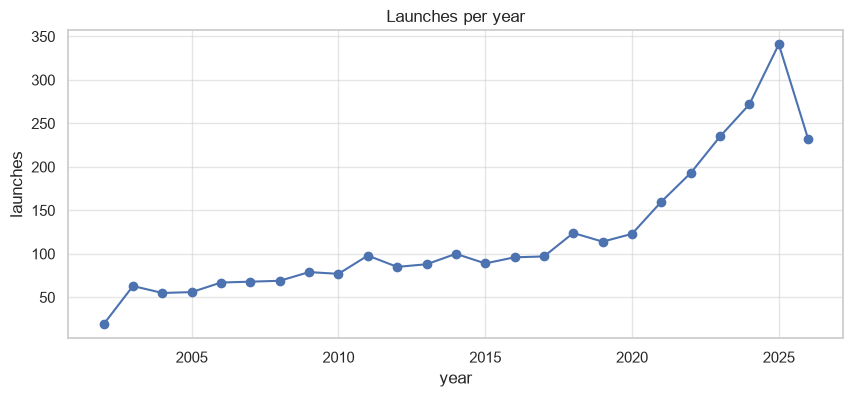

In [21]:
launches_per_year = df.groupby("year").size()
launches_per_year.plot(kind="line", marker="o", figsize=(10, 4), title="Launches per year")
plt.ylabel("launches")
plt.show()

Save the cleaned version so later notebooks can start from it.

In [22]:
df.to_csv("data/launches_clean.csv", index=False)